In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


In [19]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

train_dataset = dsets.MNIST(root='./data', 
                            train=True, 
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='./data', 
                           train=False, 
                           transform=transforms.ToTensor())


batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

## Visualization

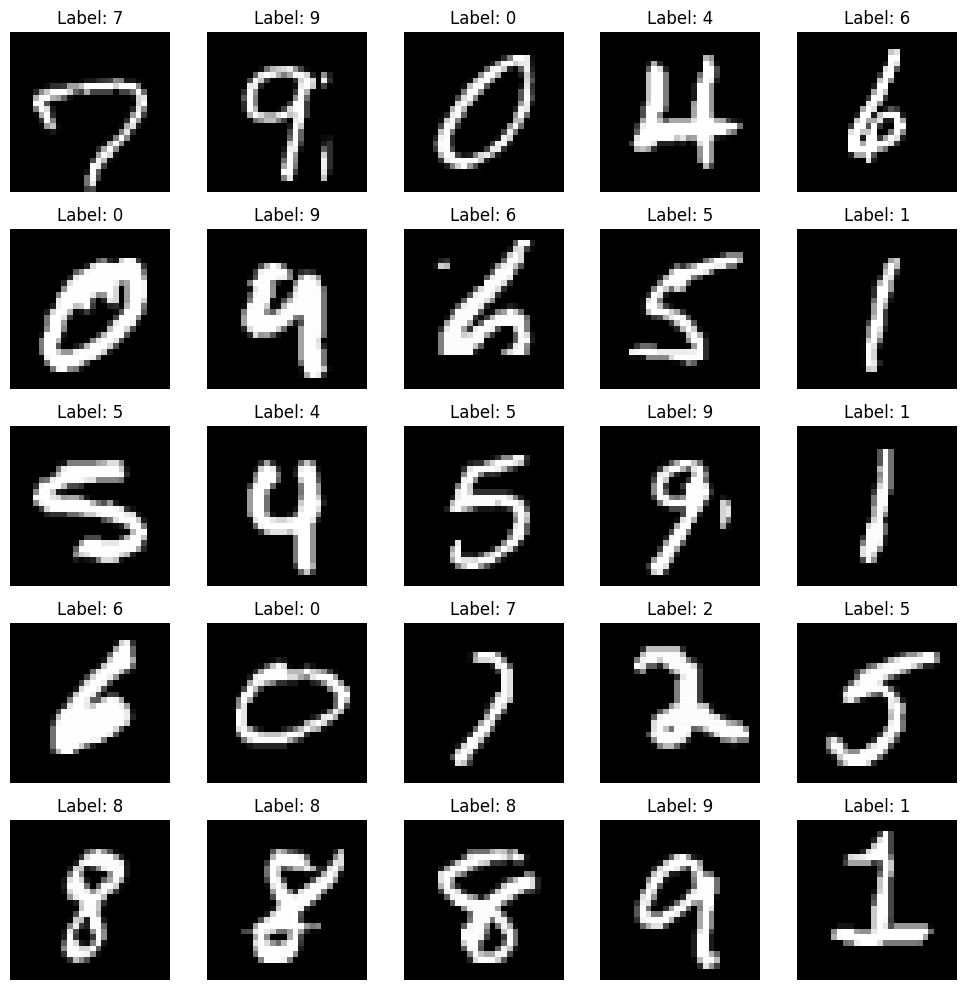

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and axis with 5x5 dimensions
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop through the train_loader to get samples
for i, (images, labels) in enumerate(train_loader):
    if i == 25:  # Only plot 25 images
        break
    
    # Display each image in the corresponding subplot
    ax = axes[i]
    ax.imshow(images[i].squeeze(), cmap='gray')  # Use squeeze to remove unnecessary dimensions
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')  # Turn off axis labels

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Create VAE Model


In [21]:
class Encoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
        self.training = True
        
    def forward(self, x):
        h       = self.LeakyReLU(self.FC_input(x))
        h       = self.LeakyReLU(self.FC_input2(h))
        mean     = self.FC_mean(h)
        log_var  = self.FC_var(h)                     # encoder produces mean and log of variance 
                                                       #             (i.e., parateters of simple tractable normal distribution "q"
        
        return mean, log_var

In [22]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        h     = self.LeakyReLU(self.FC_hidden(x))
        h     = self.LeakyReLU(self.FC_hidden2(h))
        
        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat

In [23]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)        # sampling epsilon        
        z = mean + var*epsilon                          # reparameterization trick
        return z
        
                
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat            = self.Decoder(z)
        
        return x_hat, mean, log_var

In [24]:
batch_size = 100

x_dim  = 784
hidden_dim = 400
latent_dim = 200

lr = 1e-3

epochs = 30
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim = hidden_dim, output_dim = x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)

We can represent the KL loss as follows:

![Neural network with 1 neuron](Image3.png)

For more info:
https://mbernste.github.io/posts/vae/

In [25]:
from torch.optim import Adam

BCE_loss = nn.BCELoss()

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD


optimizer = Adam(model.parameters(), lr=lr)

In [32]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
	Epoch 1 complete! 	Average Loss:  174.24516968384808
	Epoch 2 complete! 	Average Loss:  128.27101141877085
	Epoch 3 complete! 	Average Loss:  117.31540495552483
	Epoch 4 complete! 	Average Loss:  112.98818517516173
	Epoch 5 complete! 	Average Loss:  110.20003058482888
	Epoch 6 complete! 	Average Loss:  108.50525274872183
	Epoch 7 complete! 	Average Loss:  107.24289934721932
	Epoch 8 complete! 	Average Loss:  106.27691934474123
	Epoch 9 complete! 	Average Loss:  105.4113594597767
	Epoch 10 complete! 	Average Loss:  104.73372657228192
	Epoch 11 complete! 	Average Loss:  104.2229533923727
	Epoch 12 complete! 	Average Loss:  103.87201685426231
	Epoch 13 complete! 	Average Loss:  103.39823085676649
	Epoch 14 complete! 	Average Loss:  103.08020802900668
	Epoch 15 complete! 	Average Loss:  102.84431782462958
	Epoch 16 complete! 	Average Loss:  102.56454155363105
	Epoch 17 complete! 	Average Loss:  102.24293503495409
	Epoch 18 complete! 	Average Loss:  102.0784809806709


## Sampling from noise

In [43]:
with torch.no_grad():
    noise = torch.randn(batch_size, latent_dim).to(device)
    generated_images = decoder(noise)

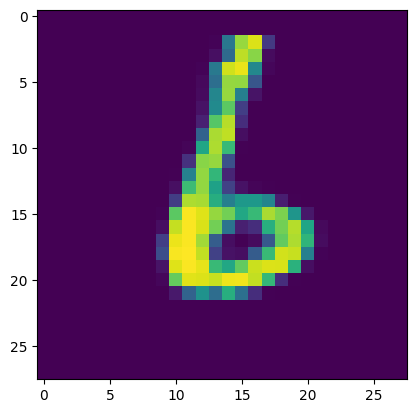

In [44]:
idx = 8
x = generated_images[idx]
x = x.view(28, 28)

fig = plt.figure()
plt.imshow(x.cpu().numpy())

## CNN-VAE

In [30]:
import torch
import torch.nn as nn

class CNNEncoder(nn.Module):
    def __init__(self, input_channels, hidden_dim, latent_dim):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling
        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling
        self.fc_mean = nn.Linear(hidden_dim * 2 * 7 * 7, latent_dim)  # Adjusted according to pooling
        self.fc_var = nn.Linear(hidden_dim * 2 * 7 * 7, latent_dim)   # Adjusted according to pooling
        self.LeakyReLU = nn.LeakyReLU(0.1)

    def forward(self, x):
        h = self.LeakyReLU(self.conv1(x))
        h = self.pool1(h)
        h = self.LeakyReLU(self.conv2(h))
        h = self.pool2(h)
        h = h.view(h.size(0), -1)  # Flattening
        mean = self.fc_mean(h)
        log_var = self.fc_var(h)
        return mean, log_var

class CNNDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_channels):
        super(CNNDecoder, self).__init__()
        self.fc_hidden = nn.Linear(latent_dim, hidden_dim * 2 * 7 * 7)  
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  
        self.conv1 = nn.Conv2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=1, padding=1)  
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=1, padding=1)  
        self.conv3 = nn.Conv2d(hidden_dim, output_channels, kernel_size=3, stride=1, padding=1)  

        self.LeakyReLU = nn.LeakyReLU(0.1)

    def forward(self, x):
        h = self.fc_hidden(x)
        h = h.view(h.size(0), -1, 7, 7)  
        h = self.LeakyReLU(self.conv1(h))  
        h = self.upsample1(h) 
        h = self.LeakyReLU(self.conv2(h))  
        h = self.upsample2(h)  
        x_hat = torch.sigmoid(self.conv3(h))  
        return x_hat

class CNNVAE(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(CNNVAE, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var)
        z = mean + var * epsilon
        return z
        
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        x_hat = self.Decoder(z)
        return x_hat, mean, log_var

In [31]:
# Model initialization code
batch_size = 100

input_channels = 1  # For grayscale images
hidden_dim = 8
latent_dim = 8

lr = 1e-3
epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Define the device

encoder = CNNEncoder(input_channels=input_channels, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = CNNDecoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_channels=input_channels)

model = CNNVAE(Encoder=encoder, Decoder=decoder).to(device)

In [32]:
from torch.optim import Adam

BCE_loss = nn.BCELoss()

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD


optimizer = Adam(model.parameters(), lr=lr)

In [33]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        #x = x.view(batch_size, x_dim)
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
	Epoch 1 complete! 	Average Loss:  178.607568815865
	Epoch 2 complete! 	Average Loss:  135.98934280115296
	Epoch 3 complete! 	Average Loss:  130.60212637925187
	Epoch 4 complete! 	Average Loss:  127.39412479457951
	Epoch 5 complete! 	Average Loss:  125.31414152167676
	Epoch 6 complete! 	Average Loss:  123.67259863444282
	Epoch 7 complete! 	Average Loss:  122.4096851197308
	Epoch 8 complete! 	Average Loss:  121.39023827146808
	Epoch 9 complete! 	Average Loss:  120.65163840776293
	Epoch 10 complete! 	Average Loss:  120.04410637194803
	Epoch 11 complete! 	Average Loss:  119.48705071603715
	Epoch 12 complete! 	Average Loss:  119.00827379943135
	Epoch 13 complete! 	Average Loss:  118.67279598484453
	Epoch 14 complete! 	Average Loss:  118.33107340358931
	Epoch 15 complete! 	Average Loss:  118.04636094336915
	Epoch 16 complete! 	Average Loss:  117.74139664740714
	Epoch 17 complete! 	Average Loss:  117.5358640214159
	Epoch 18 complete! 	Average Loss:  117.26460081581281
	

## Inference

In [37]:
with torch.no_grad():
    noise = torch.randn(batch_size, latent_dim).to(device)
    generated_images = decoder(noise)

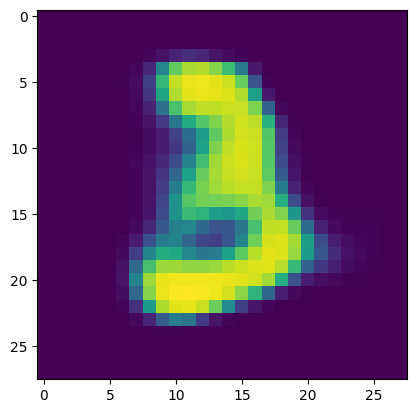

In [38]:
idx = 8
x = generated_images[idx]
x = x.view(28, 28)

fig = plt.figure()
plt.imshow(x.cpu().numpy())

## Velocity Model Generation

Download The Data:

https://drive.google.com/drive/folders/1NIdjiYhjWSV9NHn7ZEFYTpJxzvzxqYRb

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


In [2]:
import glob
pa = glob.glob('data/Vel/FlatVel_A/model/*')
vel0 = np.load(pa[0])
#vel1 = np.load(pa[1])
#vel = np.concatenate([vel0,vel1],axis=0)
vel = vel0
vel = vel/np.max(np.abs(vel))
vel.shape, vel.max(), vel.min()

((500, 1, 70, 70), np.float32(1.0), np.float32(0.33355555))

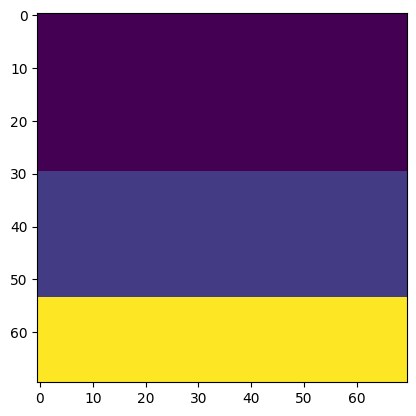

In [3]:
idx = 8
x = np.array(vel[idx,0,:,:])

fig = plt.figure()
plt.imshow(x)

In [4]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
class Encoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        
        self.ReLU = nn.ReLU()
        
        self.training = True
        
    def forward(self, x):
        h       = self.ReLU(self.FC_input(x))
        h       = self.ReLU(self.FC_input2(h))
        mean     = self.FC_mean(h)
        log_var  = self.FC_var(h)                     # encoder produces mean and log of variance 
                                                       #             (i.e., parateters of simple tractable normal distribution "q"
        
        return mean, log_var
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        
        self.ReLU = nn.ReLU()
        
    def forward(self, x):
        h     = self.ReLU(self.FC_hidden(x))
        h     = self.ReLU(self.FC_hidden2(h))
        
        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat
    
    
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)        # sampling epsilon        
        z = mean + var*epsilon                          # reparameterization trick
        return z
        
                
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat            = self.Decoder(z)
        
        return x_hat, mean, log_var

In [5]:

x_dim  = 70*70
hidden_dim = 200
latent_dim = 100

lr = 1e-4

epochs = 100
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim = hidden_dim, output_dim = x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)

In [6]:
from torch.optim import Adam

BCE_loss = nn.BCELoss()
#mse_loss = nn.MSELoss()

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    #reproduction_loss = mse_loss(x_hat, x)

    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD


optimizer = Adam(model.parameters(), lr=lr)

In [7]:
from torch.utils.data import Dataset, DataLoader

# 1. Define your Dataset class (if you haven't already):

class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)  # Convert to torch tensor
        self.labels = torch.tensor(labels, dtype=torch.float32) #Convert labels to long for classification

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [8]:
from sklearn.model_selection import train_test_split

batch_size = 8
# data and labels to tensor
datainput = torch.tensor(vel,dtype=torch.float32)
labelout = torch.tensor(vel,dtype=torch.float32)


# Divide the data into train and test
train_data, test_data, train_labels, test_labels = train_test_split(
    datainput, labelout, test_size=0.1, random_state=42)

# Create your Dataset instance
dataset_train = MyDataset(train_data, train_labels)
dataset_test  = MyDataset(test_data, test_labels)

# Create a DataLoader
# Adjust batch_size as needed; shuffle=True for training

train_loader = torch.utils.data.DataLoader(dataset=dataset_train, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=dataset_test, 
                                          batch_size=batch_size, 
                                          shuffle=False)

/tmp/ipykernel_862718/1364125503.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, dtype=torch.float32)  # Convert to torch tensor
/tmp/ipykernel_862718/1364125503.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.float32) #Convert labels to long for classification


In [9]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, xlab) in enumerate(train_loader):
        x = x.view(x.size(0), x_dim)
        x = x.to(device)

        xlab = xlab.view(xlab.size(0), x_dim)
        xlab = xlab.to(device)
        
        optimizer.zero_grad()

        x_hat, mean, log_var = model(x)

        loss = loss_function(xlab, x_hat, mean, log_var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
	Epoch 1 complete! 	Average Loss:  3365.7245243617467
	Epoch 2 complete! 	Average Loss:  3151.61400277274
	Epoch 3 complete! 	Average Loss:  3098.8296661376953
	Epoch 4 complete! 	Average Loss:  3098.5894513811386
	Epoch 5 complete! 	Average Loss:  3094.2739780970983
	Epoch 6 complete! 	Average Loss:  3091.853488377162
	Epoch 7 complete! 	Average Loss:  3086.269929068429
	Epoch 8 complete! 	Average Loss:  3090.104678562709
	Epoch 9 complete! 	Average Loss:  3086.0399540492467
	Epoch 10 complete! 	Average Loss:  3086.0389295305527
	Epoch 11 complete! 	Average Loss:  3080.4359850202286
	Epoch 12 complete! 	Average Loss:  3082.689393179757
	Epoch 13 complete! 	Average Loss:  3077.269060407366
	Epoch 14 complete! 	Average Loss:  3078.5221078055247
	Epoch 15 complete! 	Average Loss:  3070.8621215820312
	Epoch 16 complete! 	Average Loss:  3073.4923117501394
	Epoch 17 complete! 	Average Loss:  3071.1598292759486
	Epoch 18 complete! 	Average Loss:  3070.586465018136
	Epoc

## Inference

In [15]:
with torch.no_grad():
    noise = torch.randn(batch_size, latent_dim).to(device)
    generated_images = decoder(noise)

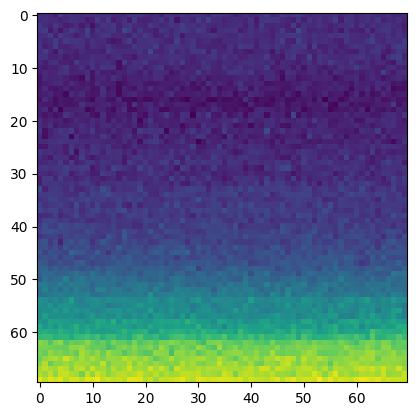

In [18]:
idx = 1
x = generated_images[idx]
x = x.view(70, 70)

fig = plt.figure()
plt.imshow(x.cpu().numpy())